In [1]:
pip install tensorflow scikit-learn numpy pandas matplotlib

  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 2.2 MB/s eta 0:02:37
   ---------------------------------------- 1.6/351.2 MB 2.7 MB/s eta 0:02:11
   ---------------------------------------- 2.4/351.2 MB 3.0 MB/s eta 0:01:58
   ---------------------------------------- 3.1/351.2 MB 3.3 MB/s eta 0:01:46
   ---------------------------------------- 4.2/351.2 MB 3.6 MB/s eta 0:01:37
    --------------------------------------- 5.5/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 6.6/351.2 MB 4.1 MB/s eta 0:01:24
    --------------------------------------- 8.1/351.2 MB 4.5 MB/s eta 0:01:18
   - -------------------------------------- 9.2/351.2 MB 4.6 MB/s eta 0:01:15
   - --------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import LabelEncoder

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: []


In [3]:
DATA_ROOT = Path(
    r"C:\Users\Sanjeev\OneDrive\Desktop\Brain ID\EEG\ds004148"
)

PROCESSED_ROOT = DATA_ROOT / "processed_windows"

TARGET_SESSIONS = [
    "ses-session1",
    "ses-session2",
    "ses-session3"
]

all_windows = []
all_labels = []
all_sessions = []

npz_files = sorted(PROCESSED_ROOT.glob("*.npz"))

print("Files:", len(npz_files))

for file in npz_files:

    stem = file.stem

    parts = stem.split("_")

    subject = parts[0]
    session = parts[1]

    if session not in TARGET_SESSIONS:
        continue

    data = np.load(file)

    windows = data["windows"]

    for window in windows:

        all_windows.append(window)
        all_labels.append(subject)
        all_sessions.append(session)

X = np.asarray(all_windows, dtype=np.float32)
y = np.asarray(all_labels)
sessions = np.asarray(all_sessions)

print("X shape:", X.shape)
print("Subjects:", len(np.unique(y)))
print("Sessions:", np.unique(sessions))

Files: 180
X shape: (8735, 3, 2000)
Subjects: 60
Sessions: ['ses-session1' 'ses-session2' 'ses-session3']


In [4]:
mean = X.mean(axis=2, keepdims=True)
std = X.std(axis=2, keepdims=True)

X = (X - mean) / (std + 1e-6)

print("Mean:", X.mean())
print("Std:", X.std())

Mean: 8.414024e-11
Std: 0.88062084


In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

NUM_CLASSES = len(label_encoder.classes_)

print("Number of classes:", NUM_CLASSES)
print("Classes:", label_encoder.classes_[:10])

Number of classes: 60
Classes: ['sub-01' 'sub-02' 'sub-03' 'sub-04' 'sub-05' 'sub-06' 'sub-07' 'sub-08'
 'sub-09' 'sub-10']


In [6]:
train_mask = np.isin(
    sessions,
    ["ses-session1", "ses-session2"]
)

test_mask = sessions == "ses-session3"

X_train_full = X[train_mask]
y_train_full = y_encoded[train_mask]

X_test = X[test_mask]
y_test = y_encoded[test_mask]

print("Training:", X_train_full.shape)
print("Testing:", X_test.shape)

Training: (6100, 3, 2000)
Testing: (2635, 3, 2000)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4880, 3, 2000)
Validation: (1220, 3, 2000)
Test: (2635, 3, 2000)


In [8]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)

(4880, 3, 2000, 1)


In [9]:
def build_eegnet(
    n_channels=3,
    n_samples=2000,
    n_classes=60
):

    inputs = layers.Input(
        shape=(n_channels, n_samples, 1)
    )

    # --------------------------------
    # Temporal convolution
    # --------------------------------

    x = layers.Conv2D(
        filters=8,
        kernel_size=(1, 64),
        padding="same",
        use_bias=False
    )(inputs)

    x = layers.BatchNormalization()(x)

    # --------------------------------
    # Depthwise spatial convolution
    # --------------------------------

    x = layers.DepthwiseConv2D(
        kernel_size=(n_channels, 1),
        depth_multiplier=2,
        padding="valid",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)

    x = layers.AveragePooling2D(
        pool_size=(1, 4)
    )(x)

    x = layers.Dropout(0.5)(x)

    # --------------------------------
    # Separable convolution
    # --------------------------------

    x = layers.SeparableConv2D(
        filters=16,
        kernel_size=(1, 16),
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)

    x = layers.AveragePooling2D(
        pool_size=(1, 8)
    )(x)

    x = layers.Dropout(0.5)(x)

    # --------------------------------
    # Classification
    # --------------------------------

    x = layers.Flatten()(x)

    embeddings = layers.Dense(
        128,
        activation=None,
        name="embedding"
    )(x)

    x = layers.BatchNormalization()(embeddings)

    outputs = layers.Dense(
        n_classes,
        activation="softmax",
        name="classifier"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs
    )

    return model

In [10]:
model = build_eegnet(
    n_channels=3,
    n_samples=2000,
    n_classes=NUM_CLASSES
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 2000, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 3, 2000, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 2000, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 2000, 16)    │            48 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 2000, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 2000, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 500, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 500, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 500, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 500, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 500, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 62, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 62, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 992)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │       127,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 60)             │         7,740 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,588 (533.55 KB)

 Trainable params: 136,252 (532.23 KB)

 Non-trainable params: 336 (1.31 KB)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.0459 - loss: 3.9896 - val_accuracy: 0.0295 - val_loss: 3.8682 - learning_rate: 0.0010
Epoch 2/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.0957 - loss: 3.3433 - val_accuracy: 0.0672 - val_loss: 3.5031 - learning_rate: 0.0010
Epoch 3/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 104ms/step - accuracy: 0.1266 - loss: 3.2091 - val_accuracy: 0.0836 - val_loss: 3.4747 - learning_rate: 0.0010
Epoch 4/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.1605 - loss: 3.0553 - val_accuracy: 0.1008 - val_loss: 3.3107 - learning_rate: 0.0010
Epoch 5/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - accuracy: 0.2105 - loss: 2.8302 - val_accuracy: 0.1672 - val_loss: 3.1856 - learning_rate: 0.0010
Epoch 6/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.2740 - loss: 2.5933 - val_accuracy: 0.2164 - val_loss: 2.9844 - learning_rate: 0.0010
Epoch 7/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accura

In [13]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    accuracy_score,
    confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create model that outputs the learned embedding
embedding_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer("embedding").output
)

# Extract embeddings
train_embeddings = embedding_model.predict(
    X_train,
    batch_size=64,
    verbose=1
)

val_embeddings = embedding_model.predict(
    X_val,
    batch_size=64,
    verbose=1
)

test_embeddings = embedding_model.predict(
    X_test,
    batch_size=64,
    verbose=1
)

print("Train embeddings:", train_embeddings.shape)
print("Validation embeddings:", val_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)

77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
Train embeddings: (4880, 128)
Validation embeddings: (1220, 128)
Test embeddings: (2635, 128)


In [14]:
y_train
y_val
y_test

array([ 0,  0,  0, ..., 59, 59, 59], shape=(2635,))

In [15]:
train_subjects = label_encoder.inverse_transform(y_train)
val_subjects = label_encoder.inverse_transform(y_val)
test_subjects = label_encoder.inverse_transform(y_test)

print("Test subjects:", np.unique(test_subjects))

Test subjects: ['sub-01' 'sub-02' 'sub-03' 'sub-04' 'sub-05' 'sub-06' 'sub-07' 'sub-08'
 'sub-09' 'sub-10' 'sub-11' 'sub-12' 'sub-14' 'sub-15' 'sub-16' 'sub-17'
 'sub-18' 'sub-19' 'sub-20' 'sub-21' 'sub-22' 'sub-23' 'sub-24' 'sub-25'
 'sub-26' 'sub-27' 'sub-28' 'sub-29' 'sub-30' 'sub-31' 'sub-32' 'sub-34'
 'sub-35' 'sub-36' 'sub-37' 'sub-38' 'sub-39' 'sub-40' 'sub-41' 'sub-42'
 'sub-43' 'sub-44' 'sub-45' 'sub-46' 'sub-47' 'sub-48' 'sub-49' 'sub-50'
 'sub-51' 'sub-52' 'sub-53' 'sub-54' 'sub-55' 'sub-57' 'sub-58' 'sub-59'
 'sub-60']


In [16]:
enrollment_templates = {}

for subject in np.unique(train_subjects):

    subject_embeddings = train_embeddings[
        train_subjects == subject
    ]

    # Average embedding = subject template
    template = np.mean(
        subject_embeddings,
        axis=0
    )

    # Normalize template
    norm = np.linalg.norm(template)

    if norm > 0:
        template = template / norm

    enrollment_templates[subject] = template

print(
    "Enrollment templates:",
    len(enrollment_templates)
)

Enrollment templates: 60


In [17]:
test_embeddings_norm = test_embeddings / (
    np.linalg.norm(
        test_embeddings,
        axis=1,
        keepdims=True
    ) + 1e-8
)

In [18]:
subjects = sorted(enrollment_templates.keys())

genuine_scores = []
impostor_scores = []

for i, true_subject in enumerate(test_subjects):

    test_embedding = test_embeddings_norm[i]

    for subject in subjects:

        template = enrollment_templates[subject]

        score = np.dot(
            test_embedding,
            template
        )

        if subject == true_subject:

            genuine_scores.append(score)

        else:

            impostor_scores.append(score)

genuine_scores = np.asarray(genuine_scores)
impostor_scores = np.asarray(impostor_scores)

print("Genuine scores:", len(genuine_scores))
print("Impostor scores:", len(impostor_scores))

print(
    "Mean genuine:",
    genuine_scores.mean()
)

print(
    "Mean impostor:",
    impostor_scores.mean()
)

Genuine scores: 2635
Impostor scores: 155465
Mean genuine: 0.2778293
Mean impostor: 0.09543395


In [19]:
y_true = np.concatenate([
    np.ones(len(genuine_scores)),
    np.zeros(len(impostor_scores))
])

y_scores = np.concatenate([
    genuine_scores,
    impostor_scores
])

print("Total comparisons:", len(y_true))

Total comparisons: 158100


In [20]:
auc = roc_auc_score(
    y_true,
    y_scores
)

print("ROC-AUC:", auc)

ROC-AUC: 0.656256945024631


In [21]:
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_scores
)

far = fpr
tar = tpr
frr = 1 - tpr

# Find point where FAR and FRR are closest
eer_index = np.nanargmin(
    np.abs(far - frr)
)

eer = (far[eer_index] + frr[eer_index]) / 2

eer_threshold = thresholds[eer_index]

print("=" * 50)
print("EEG AUTHENTICATION RESULTS")
print("=" * 50)

print(f"EER           : {eer:.6f}")
print(f"EER %         : {eer * 100:.2f}%")
print(f"EER Threshold : {eer_threshold:.6f}")
print(f"FAR @ EER     : {far[eer_index]:.6f}")
print(f"FRR @ EER     : {frr[eer_index]:.6f}")
print(f"TAR @ EER     : {tar[eer_index]:.6f}")
print(f"TAR %         : {tar[eer_index] * 100:.2f}%")
print(f"ROC-AUC       : {auc:.6f}")

EEG AUTHENTICATION RESULTS
EER           : 0.399620
EER %         : 39.96%
EER Threshold : 0.170964
FAR @ EER     : 0.399620
FRR @ EER     : 0.399620
TAR @ EER     : 0.600380
TAR %         : 60.04%
ROC-AUC       : 0.656257


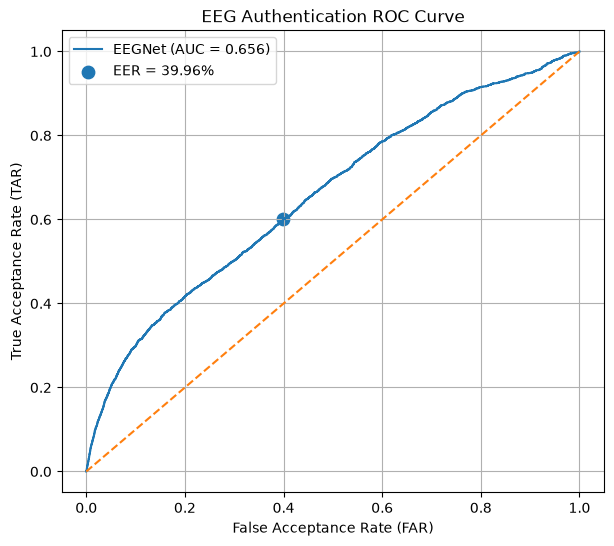

In [22]:
plt.figure(figsize=(7, 6))

plt.plot(
    far,
    tar,
    label=f"EEGNet (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.scatter(
    far[eer_index],
    tar[eer_index],
    s=80,
    label=f"EER = {eer * 100:.2f}%"
)

plt.xlabel("False Acceptance Rate (FAR)")
plt.ylabel("True Acceptance Rate (TAR)")
plt.title("EEG Authentication ROC Curve")

plt.legend()
plt.grid(True)
plt.show()

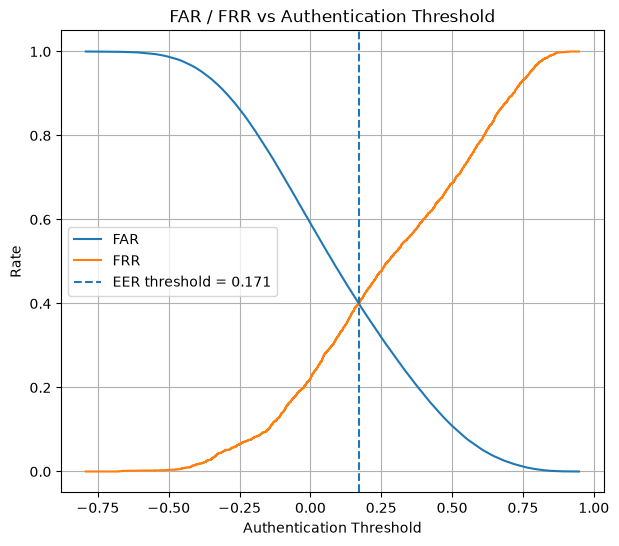

In [23]:
plt.figure(figsize=(7, 6))

plt.plot(
    thresholds,
    far,
    label="FAR"
)

plt.plot(
    thresholds,
    frr,
    label="FRR"
)

plt.axvline(
    eer_threshold,
    linestyle="--",
    label=f"EER threshold = {eer_threshold:.3f}"
)

plt.xlabel("Authentication Threshold")
plt.ylabel("Rate")
plt.title("FAR / FRR vs Authentication Threshold")

plt.legend()
plt.grid(True)
plt.show()

In [24]:
predicted_labels = (
    y_scores >= eer_threshold
).astype(int)

auth_accuracy = accuracy_score(
    y_true,
    predicted_labels
)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    predicted_labels
).ravel()

print("=" * 50)
print("AUTHENTICATION PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {auth_accuracy * 100:.2f}%")
print(f"TP       : {tp}")
print(f"TN       : {tn}")
print(f"FP       : {fp}")
print(f"FN       : {fn}")

AUTHENTICATION PERFORMANCE
Accuracy : 60.04%
TP       : 1582
TN       : 93338
FP       : 62127
FN       : 1053


In [25]:
results = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "EER",
        "EER (%)",
        "EER Threshold",
        "FAR @ EER",
        "FRR @ EER",
        "TAR @ EER",
        "TAR @ EER (%)",
        "Authentication Accuracy"
    ],
    "Value": [
        auc,
        eer,
        eer * 100,
        eer_threshold,
        far[eer_index],
        frr[eer_index],
        tar[eer_index],
        tar[eer_index] * 100,
        auth_accuracy * 100
    ]
})

results

,Metric,Value
0,ROC-AUC,0.656257
1,EER,0.399620
2,EER (%),39.962049
3,EER Threshold,0.170964
4,FAR @ EER,0.399620
5,FRR @ EER,0.399620
6,TAR @ EER,0.600380
7,TAR @ EER (%),60.037951
8,Authentication Accuracy,60.037951
